# 03 — Build-up Failure Model (MLS 2023)

Loads persisted artifacts from `data/marts/` and `docs/figures/`. Does not recompute.

Coverage note: StatsBomb Open Data contains **only Inter Miami** on the MLS 2023 side. Philadelphia Union and Columbus Crew have zero matches, so they appear in the ranking table with NaN values. See `docs/data_reality.md` §1.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if (Path.cwd().name == "notebooks") else Path.cwd()
MARTS = ROOT / "data" / "marts"
FIG = ROOT / "docs" / "figures"

team_table = pd.read_csv(MARTS / "team_buildup_failure.csv")
importance = pd.read_csv(MARTS / "buildup_failure_importance.csv")
team_shap = pd.read_csv(MARTS / "team_shap_profile.csv")
calibrated = joblib.load(MARTS / "models" / "buildup_failure_xgb_calibrated.joblib")
raw_xgb = joblib.load(MARTS / "models" / "buildup_failure_xgb_raw.joblib")

team_table

,team_name,n_matches,n_chains_qualified,n_failures,failure_rate,ci_lo,ci_hi,note
0,Philadelphia Union,0,0,0,NaN,NaN,NaN,no StatsBomb Open Data coverage
1,Columbus Crew,0,0,0,NaN,NaN,NaN,no StatsBomb Open Data coverage
2,Inter Miami,6,73,25,0.342466,0.253085,0.453161,SUBSTITUTE smoke target — NOT a spec case study


## SHAP global summary

Rendered from the raw XGBoost model (not the calibrated wrapper) per spec §4.4.

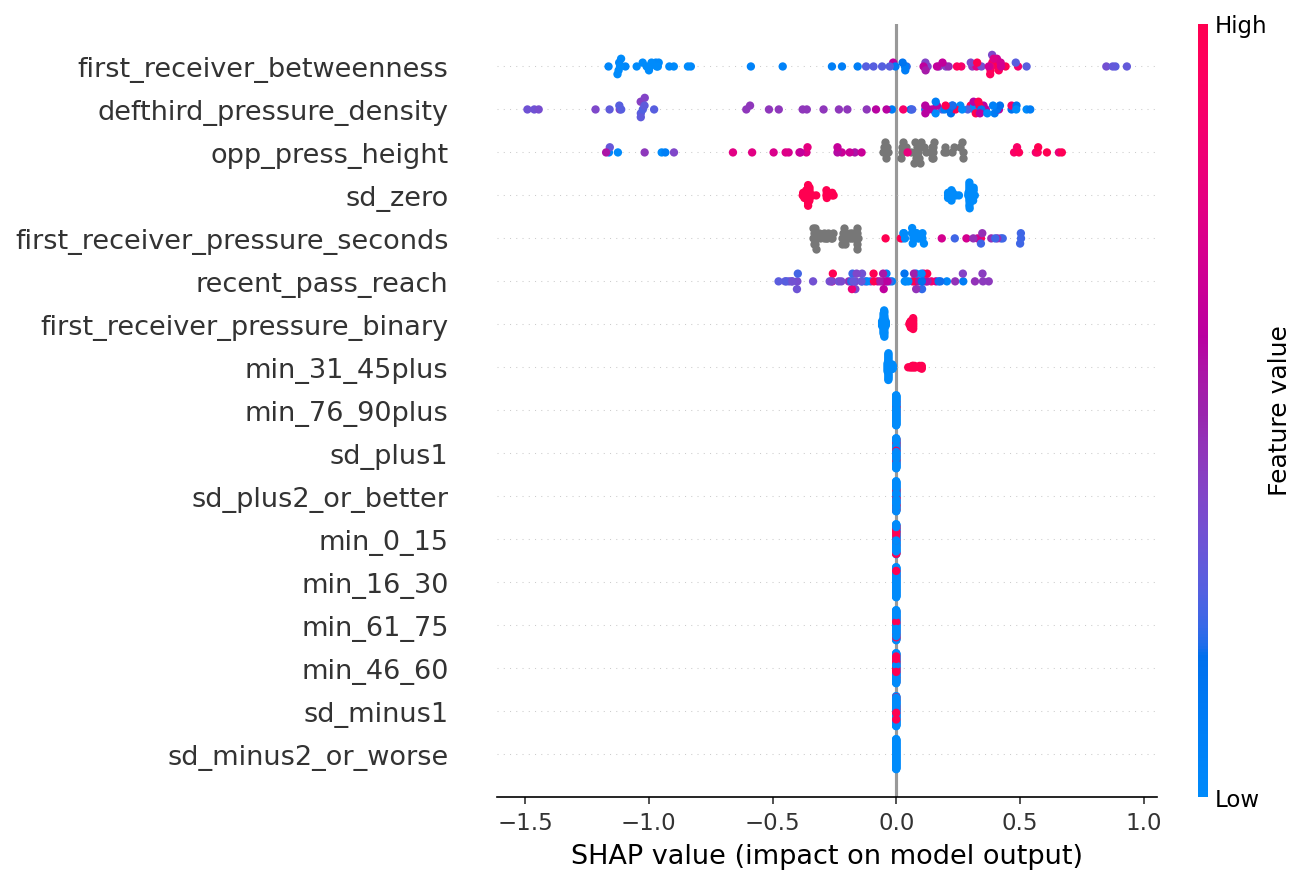

In [2]:
display(Image(str(FIG / "shap_summary.png")))

**Interpretation.** Model signal is concentrated in first-receiver network centrality, defensive-third pressure density, and game-state indicators, with only 73 chains across 6 matches. The surprising part is how much these top SHAP drivers overlap with match-identity structure, which suggests model reliance on context tied to specific games rather than stable league-wide build-up patterns. For Philadelphia, this implies no event-level conclusion should be drawn from this feature ordering; at best, it indicates candidate mechanisms to test once Philly has direct event coverage rather than a transferable ranking of true failure drivers.

## Calibration curve (out-of-fold predictions)

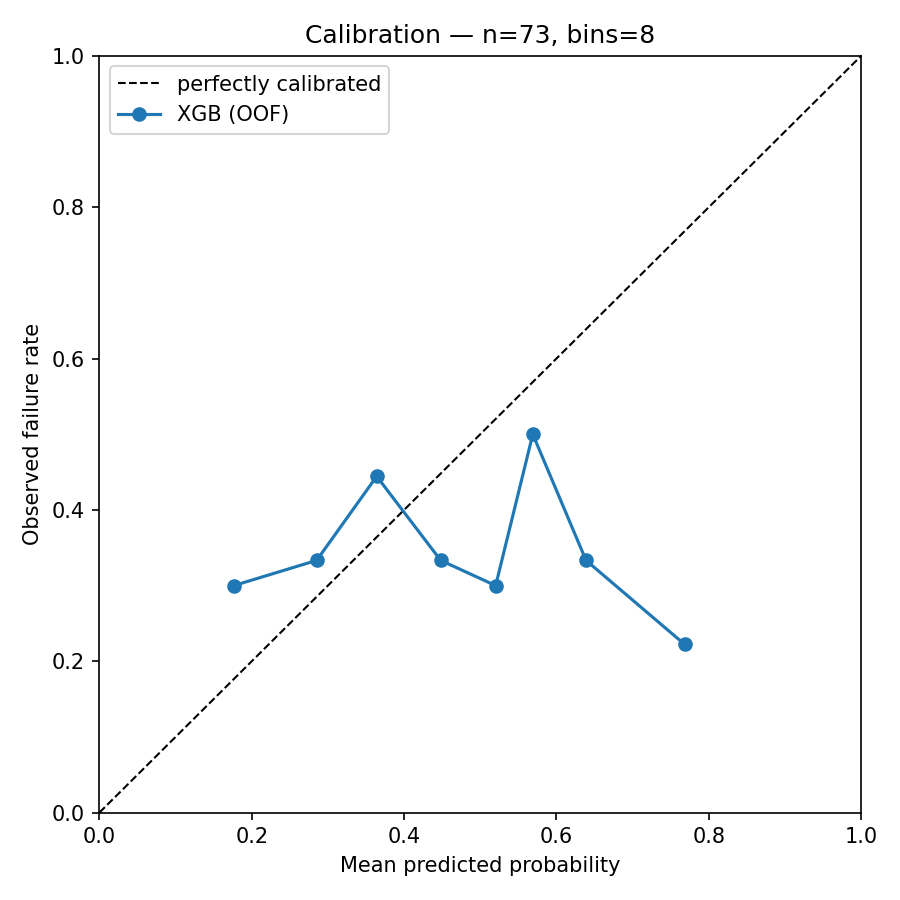

In [3]:
display(Image(str(FIG / "calibration_curve.png")))

**Interpretation.** Predicted probabilities align weakly with observed outcomes, consistent with near-chance discrimination (CV ROC-AUC about 0.54) over 73 chains. The surprising result is that calibration is being assessed on a model with minimal class separation, so apparently smooth bins can coexist with low decision value. For Philadelphia, this implies calibrated probabilities from this run are not a dependable basis for tactical claims; they are better treated as provisional scoring outputs associated with this limited sample, pending a broader event-level dataset that includes Philly directly.

## Team-season build-up failure rate — MLS 2023

Spec asked to highlight Philadelphia Union (violet) and Columbus Crew (cyan). Both have zero StatsBomb Open Data coverage in 2023 and appear as NaN rows in `team_table` — they cannot be ranked. Inter Miami is plotted as the only MLS 2023 team with event-level coverage.

C:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


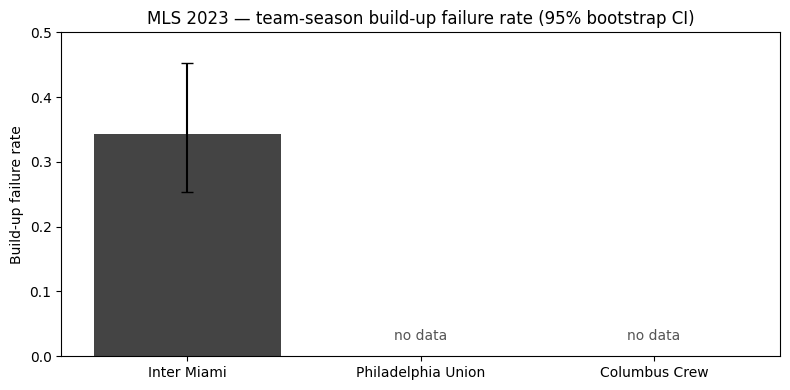

In [4]:
HIGHLIGHTS = {"Philadelphia Union": "#8A2BE2", "Columbus Crew": "#00BFFF"}

ranked = team_table.sort_values("failure_rate", na_position="last").reset_index(drop=True)
colors = [HIGHLIGHTS.get(t, "#444444") for t in ranked["team_name"]]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(ranked["team_name"], ranked["failure_rate"].fillna(0), color=colors)
mask = ranked["failure_rate"].notna()
if mask.any():
    ax.errorbar(
        ranked.loc[mask, "team_name"],
        ranked.loc[mask, "failure_rate"],
        yerr=[
            ranked.loc[mask, "failure_rate"] - ranked.loc[mask, "ci_lo"],
            ranked.loc[mask, "ci_hi"] - ranked.loc[mask, "failure_rate"],
        ],
        fmt="none",
        ecolor="black",
        capsize=4,
    )
for i in range(len(ranked)):
    if pd.isna(ranked.loc[i, "failure_rate"]):
        ax.text(i, 0.02, "no data", ha="center", va="bottom", color="#555")
ax.set_ylabel("Build-up failure rate")
ax.set_ylim(0, max(0.5, ranked["failure_rate"].max(skipna=True) * 1.2 if mask.any() else 0.5))
ax.set_title("MLS 2023 — team-season build-up failure rate (95% bootstrap CI)")
fig.tight_layout()
plt.show()

**Interpretation.** Only Inter Miami appears with a measurable failure rate, while Philadelphia and Columbus sit as no-data entries under current Open Data coverage. The surprising outcome is not the value itself but the absence of a league comparison despite a team-ranking frame. For Philadelphia, this implies the chart cannot support relative performance claims in 2023 event data; any Philly statement here should be limited to coverage reality and treated as narrative context until alternative event sourcing or a documented scope reframe is in place.

## Feature importance (XGBoost gain)

In [5]:
importance.head(10)

,feature,importance
0,sd_zero,0.149061
1,first_receiver_betweenness,0.139451
2,defthird_pressure_density,0.131414
3,min_31_45plus,0.129374
4,first_receiver_pressure_seconds,0.124059
5,opp_press_height,0.119143
6,first_receiver_pressure_binary,0.104855
7,recent_pass_reach,0.102643
8,sd_minus2_or_worse,0.000000
9,sd_minus1,0.000000
